In [2]:
import sys
sys.path.append("../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.metrics import confusion_matrix

from src.data_loader import load_csv
from src.preprocessing import remove_duplicates, convert_datetime_columns, convert_column_to_int
from src.geolocation import merge_ip_country
from src.feature_engineering import add_time_features, add_transaction_features
from src.transformation import prepare_training_data



In [9]:
fraud = load_csv("../data/raw/Fraud_Data.csv")
ip_country = load_csv("../data/raw/IpAddress_to_Country.csv")

fraud = remove_duplicates(fraud)
fraud = convert_datetime_columns(fraud, ["signup_time", "purchase_time"])
fraud = convert_column_to_int(fraud, "ip_address")

fraud_geo = merge_ip_country(fraud, ip_country)
fraud_geo = add_time_features(fraud_geo)
fraud_geo = add_transaction_features(fraud_geo)

X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = prepare_training_data(
    fraud_geo,
    target_column="class",
    drop_columns=["signup_time", "purchase_time", "device_id", "user_id"]
)

Before SMOTE:
class
0    109568
1     11321
Name: count, dtype: int64
After SMOTE:
class
0    109568
1    109568
Name: count, dtype: int64


In [10]:
fraud_rf = joblib.load("../models/fraud_random_forest.pkl")

In [11]:
feature_names = pd.get_dummies(
    fraud_geo.drop(columns=["class", "signup_time", "purchase_time", "device_id", "user_id"]),
    drop_first=True
).columns

importances = fraud_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_10_features = feature_importance_df.head(10)
top_10_features

,feature,importance
9,device_transaction_count,0.468901
10,transaction_velocity,0.230206
7,time_since_signup_hours,0.217629
6,day_of_week,0.019350
5,hour_of_day,0.009194
12,source_SEO,0.008932
17,sex_M,0.007295
1,age,0.005988
0,purchase_value,0.005019
4,upper_bound_ip_address,0.003705


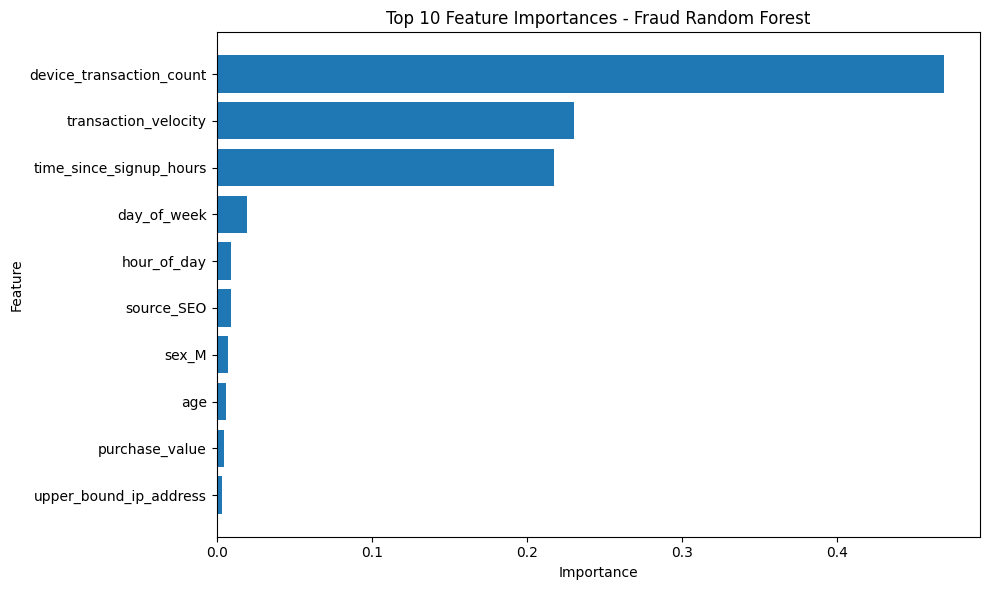

In [12]:
plt.figure(figsize=(10, 6))
plt.barh(top_10_features["feature"], top_10_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Fraud Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/fraud_top10_feature_importance.png")
plt.show()

X_test_fraud_sample shape: (1000, 199)
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1000, 199, 2)
Final SHAP class 1 shape: (1000, 199)


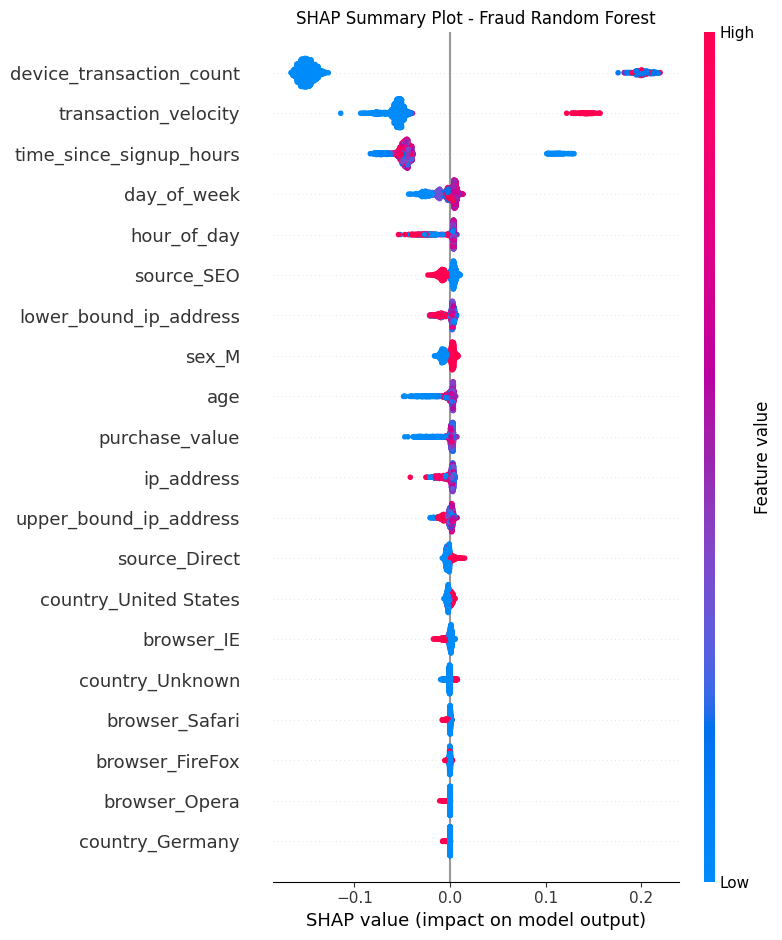

In [13]:
X_test_fraud_sample = X_test_fraud[:1000]

explainer = shap.TreeExplainer(fraud_rf)
shap_values = explainer.shap_values(X_test_fraud_sample)

print("X_test_fraud_sample shape:", X_test_fraud_sample.shape)
print("SHAP values type:", type(shap_values))

if isinstance(shap_values, list):
    print("SHAP class 0 shape:", shap_values[0].shape)
    print("SHAP class 1 shape:", shap_values[1].shape)
    shap_values_class_1 = shap_values[1]
else:
    print("SHAP values shape:", shap_values.shape)

    if len(shap_values.shape) == 3:
        shap_values_class_1 = shap_values[:, :, 1]
    else:
        shap_values_class_1 = shap_values

print("Final SHAP class 1 shape:", shap_values_class_1.shape)

shap.summary_plot(
    shap_values_class_1,
    X_test_fraud_sample,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot - Fraud Random Forest")
plt.tight_layout()
plt.savefig("../reports/fraud_shap_summary.png", bbox_inches="tight")
plt.show()

# Credit Card Model Explainability

In [3]:
credit = load_csv("../data/raw/creditcard.csv")
credit = remove_duplicates(credit)
credit = convert_column_to_int(credit, "Class")

X_train_credit, X_test_credit, y_train_credit, y_test_credit = prepare_training_data(
    credit,
    target_column="Class"
)

credit_rf = joblib.load("../models/credit_random_forest.pkl")

credit_feature_names = credit.drop(columns=["Class"]).columns

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [4]:
credit_importances = credit_rf.feature_importances_

credit_feature_importance_df = pd.DataFrame({
    "feature": credit_feature_names,
    "importance": credit_importances
}).sort_values("importance", ascending=False)

credit_top_10_features = credit_feature_importance_df.head(10)

credit_top_10_features

,feature,importance
14,V14,0.206581
10,V10,0.128222
12,V12,0.101645
17,V17,0.097511
4,V4,0.092203
11,V11,0.058641
3,V3,0.058295
16,V16,0.057494
2,V2,0.039540
9,V9,0.024429


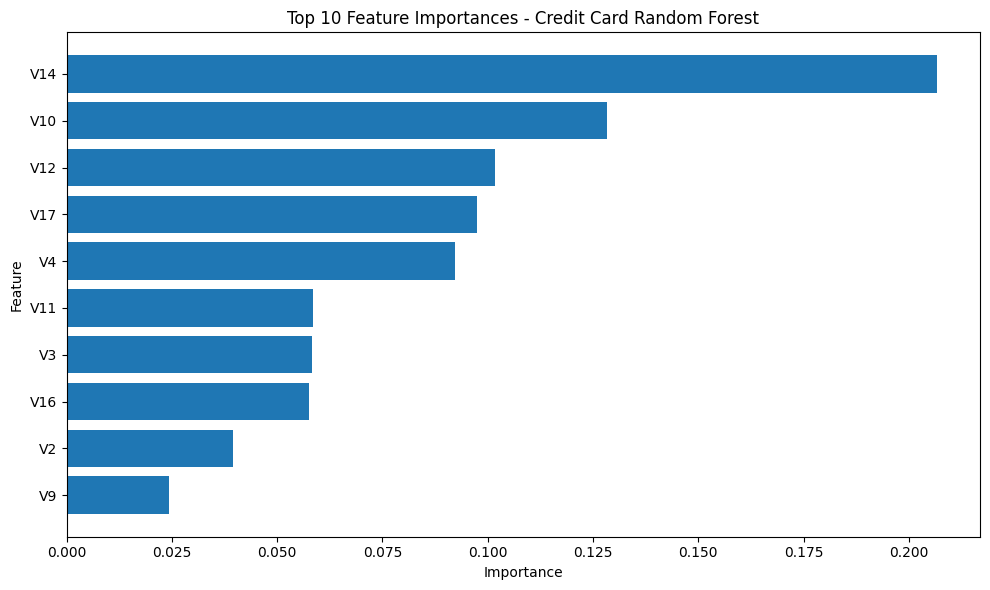

In [5]:
plt.figure(figsize=(10, 6))
plt.barh(
    credit_top_10_features["feature"],
    credit_top_10_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Credit Card Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/credit_top10_feature_importance.png", bbox_inches="tight")
plt.show()

Credit test sample shape: (1000, 30)
Credit SHAP class 1 shape: (1000, 30)


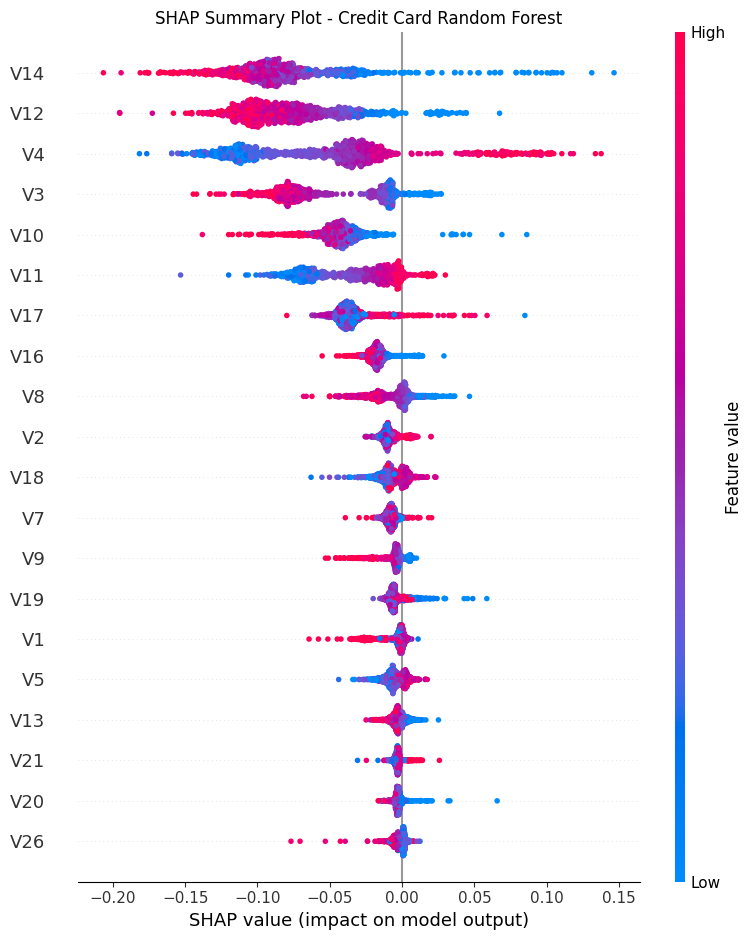

In [6]:
X_test_credit_sample = X_test_credit[:1000]

credit_explainer = shap.TreeExplainer(credit_rf)
credit_shap_values = credit_explainer.shap_values(X_test_credit_sample)

if isinstance(credit_shap_values, list):
    credit_shap_values_class_1 = credit_shap_values[1]
else:
    if len(credit_shap_values.shape) == 3:
        credit_shap_values_class_1 = credit_shap_values[:, :, 1]
    else:
        credit_shap_values_class_1 = credit_shap_values

print("Credit test sample shape:", X_test_credit_sample.shape)
print("Credit SHAP class 1 shape:", credit_shap_values_class_1.shape)

shap.summary_plot(
    credit_shap_values_class_1,
    X_test_credit_sample,
    feature_names=credit_feature_names,
    show=False
)

plt.title("SHAP Summary Plot - Credit Card Random Forest")
plt.tight_layout()
plt.savefig("../reports/credit_shap_summary.png", bbox_inches="tight")
plt.show()

In [16]:
y_pred_fraud_sample = fraud_rf.predict(X_test_fraud_sample)
y_test_fraud_sample = y_test_fraud.iloc[:1000].reset_index(drop=True)

prediction_df = pd.DataFrame({
    "actual": y_test_fraud_sample.values,
    "predicted": y_pred_fraud_sample
})

tp_index = prediction_df[
    (prediction_df["actual"] == 1) & 
    (prediction_df["predicted"] == 1)
].index[0]

fp_index = prediction_df[
    (prediction_df["actual"] == 0) & 
    (prediction_df["predicted"] == 1)
].index[0]

fn_index = prediction_df[
    (prediction_df["actual"] == 1) & 
    (prediction_df["predicted"] == 0)
].index[0]

tp_index, fp_index, fn_index

(np.int64(17), np.int64(21), np.int64(2))

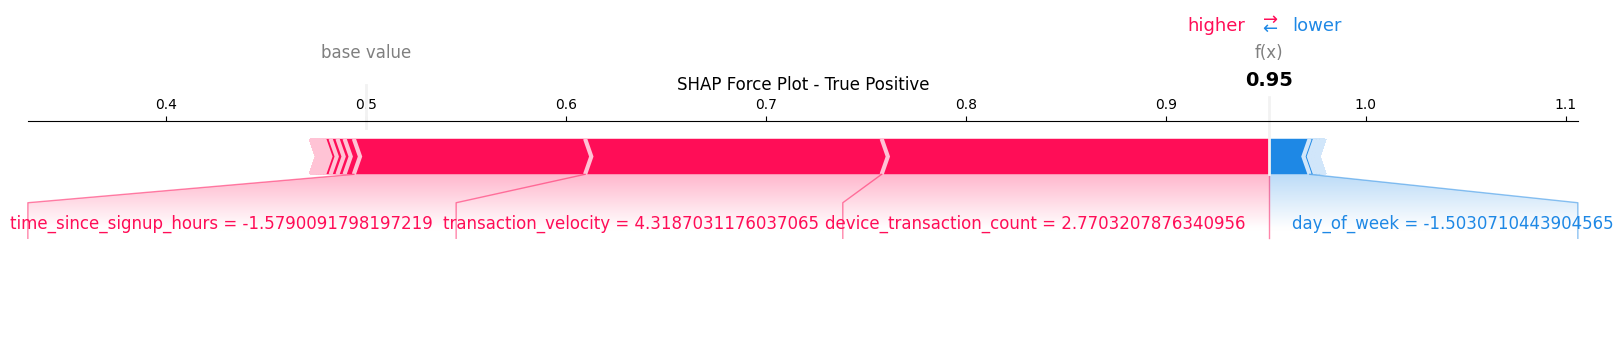

In [17]:
base_value = explainer.expected_value[1]

X_test_fraud_sample_df = pd.DataFrame(
    X_test_fraud_sample,
    columns=feature_names
)

# True Positive
shap.force_plot(
    base_value,
    shap_values_class_1[tp_index],
    X_test_fraud_sample_df.iloc[tp_index],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)

plt.title("SHAP Force Plot - True Positive")
plt.savefig("../reports/fraud_force_plot_true_positive.png", bbox_inches="tight")
plt.show()

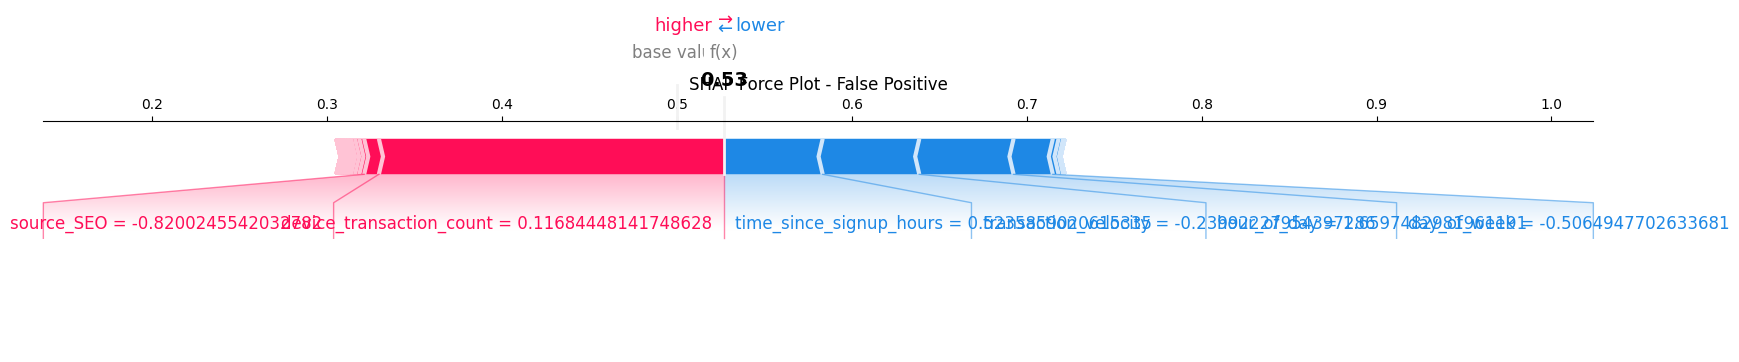

In [18]:
# False Positive
shap.force_plot(
    base_value,
    shap_values_class_1[fp_index],
    X_test_fraud_sample_df.iloc[fp_index],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)

plt.title("SHAP Force Plot - False Positive")
plt.savefig("../reports/fraud_force_plot_false_positive.png", bbox_inches="tight")
plt.show()

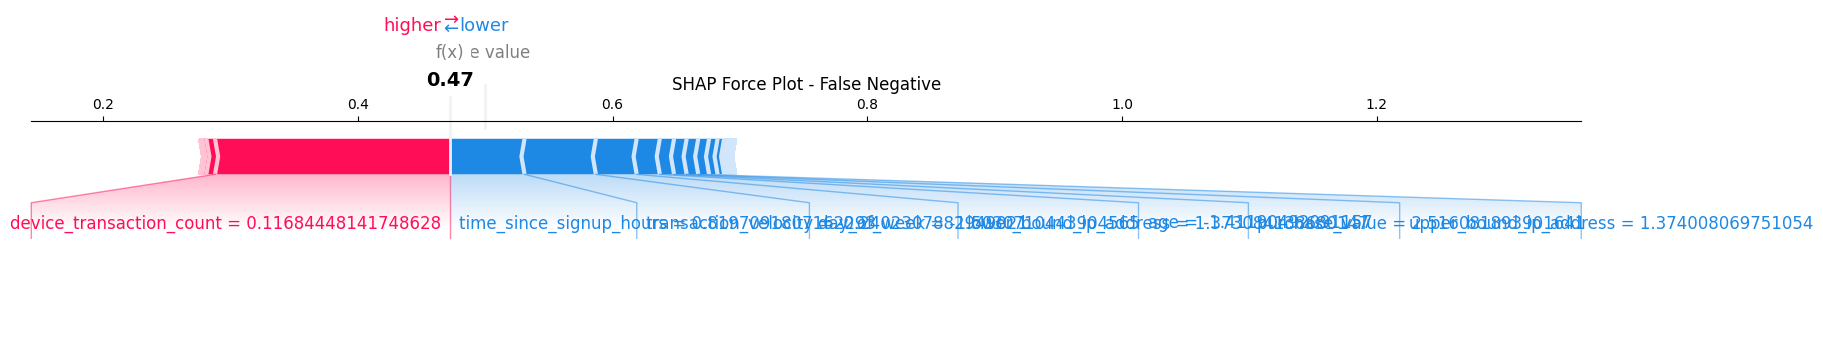

In [19]:
# False Negative
shap.force_plot(
    base_value,
    shap_values_class_1[fn_index],
    X_test_fraud_sample_df.iloc[fn_index],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)

plt.title("SHAP Force Plot - False Negative")
plt.savefig("../reports/fraud_force_plot_false_negative.png", bbox_inches="tight")
plt.show()

In [8]:
# Predict on the full credit card test set
y_pred_credit_full = credit_rf.predict(X_test_credit)

credit_prediction_df_full = pd.DataFrame({
    "actual": y_test_credit.values,
    "predicted": y_pred_credit_full
})

print("Prediction case counts:")
print(pd.crosstab(
    credit_prediction_df_full["actual"],
    credit_prediction_df_full["predicted"],
    rownames=["Actual"],
    colnames=["Predicted"]
))

# Find True Positive, False Positive, and False Negative from full test set
credit_tp_index = credit_prediction_df_full[
    (credit_prediction_df_full["actual"] == 1) &
    (credit_prediction_df_full["predicted"] == 1)
].index[0]

credit_fp_index = credit_prediction_df_full[
    (credit_prediction_df_full["actual"] == 0) &
    (credit_prediction_df_full["predicted"] == 1)
].index[0]

credit_fn_index = credit_prediction_df_full[
    (credit_prediction_df_full["actual"] == 1) &
    (credit_prediction_df_full["predicted"] == 0)
].index[0]

credit_tp_index, credit_fp_index, credit_fn_index

Prediction case counts:
Predicted      0   1
Actual              
0          56588  63
1             17  78


(np.int64(845), np.int64(1203), np.int64(4480))

In [9]:
# Create a small explanation dataset containing exactly the 3 cases we need
credit_case_indices = [credit_tp_index, credit_fp_index, credit_fn_index]

X_credit_cases = X_test_credit[credit_case_indices]

credit_case_labels = ["True Positive", "False Positive", "False Negative"]

X_credit_cases_df = pd.DataFrame(
    X_credit_cases,
    columns=credit_feature_names
)

X_credit_cases_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.436767,-0.797938,1.099801,-0.634022,1.563287,-1.486180,-0.688754,-1.964285,1.023983,-1.531454,...,0.513671,1.182511,1.069450,0.094722,0.566441,-0.899456,-0.578839,1.598250,1.211444,-0.046577
1,0.514756,0.594115,-0.667110,-1.597884,0.773496,-0.075869,-0.723599,0.592778,-0.206521,0.592703,...,0.796799,0.187389,-0.422415,-0.453413,-0.240495,-0.091475,-0.739321,-0.174899,0.156064,1.354753
2,1.251024,-0.045197,-2.382601,-1.737476,0.116683,-1.034019,-0.610140,1.249898,-0.402607,1.391731,...,2.472604,0.971413,-0.251776,-1.471614,0.184204,-0.137777,-2.339476,-0.441984,0.384573,4.103907


In [10]:
credit_case_shap_values = credit_explainer.shap_values(X_credit_cases)

if isinstance(credit_case_shap_values, list):
    credit_case_shap_values_class_1 = credit_case_shap_values[1]
else:
    if len(credit_case_shap_values.shape) == 3:
        credit_case_shap_values_class_1 = credit_case_shap_values[:, :, 1]
    else:
        credit_case_shap_values_class_1 = credit_case_shap_values

print("Credit case SHAP shape:", credit_case_shap_values_class_1.shape)

Credit case SHAP shape: (3, 30)


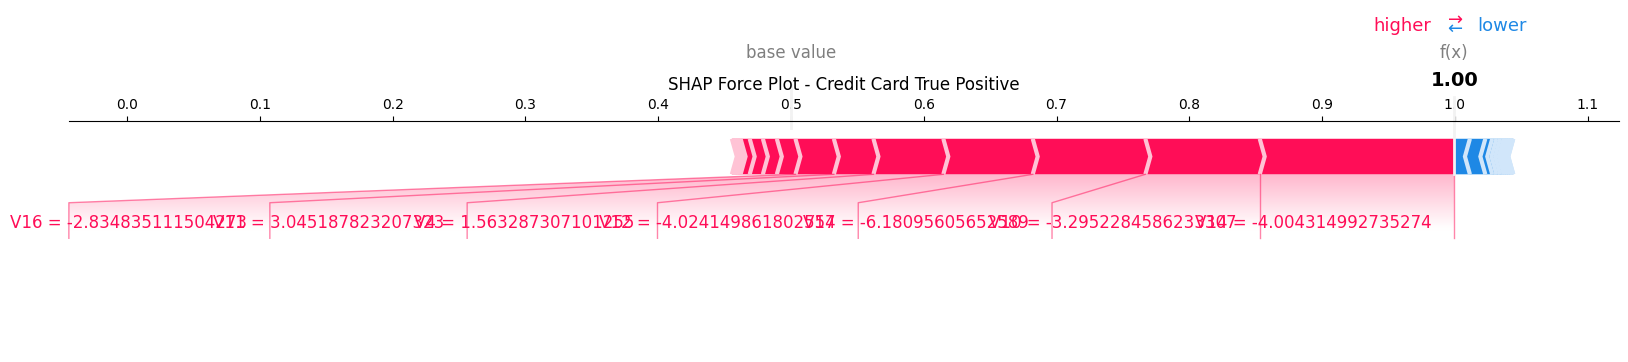

In [11]:
credit_base_value = credit_explainer.expected_value[1]

shap.force_plot(
    credit_base_value,
    credit_case_shap_values_class_1[0],
    X_credit_cases_df.iloc[0],
    feature_names=credit_feature_names,
    matplotlib=True,
    show=False
)

plt.title("SHAP Force Plot - Credit Card True Positive")
plt.savefig("../reports/credit_force_plot_true_positive.png", bbox_inches="tight")
plt.show()

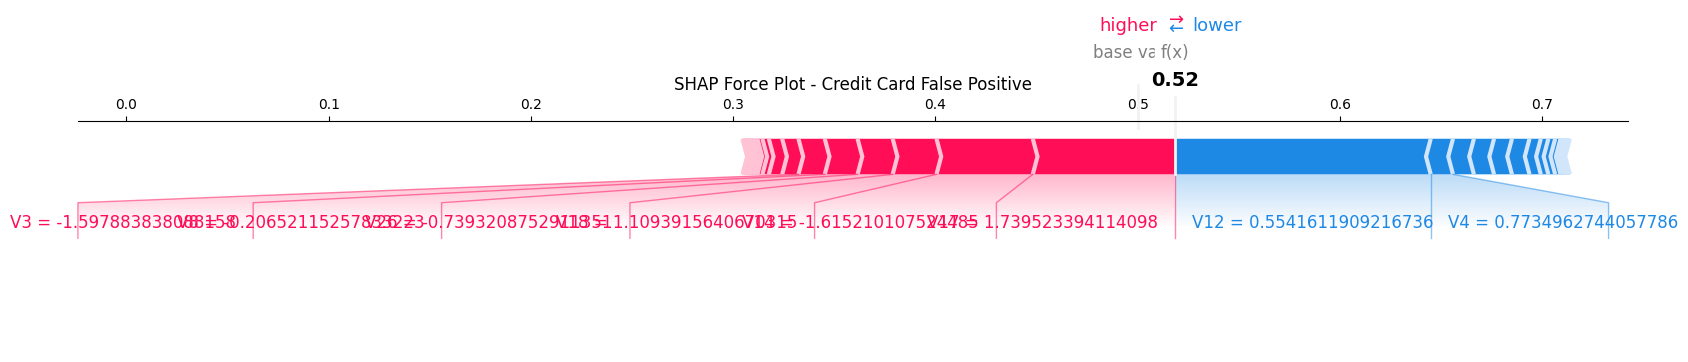

In [12]:
shap.force_plot(
    credit_base_value,
    credit_case_shap_values_class_1[1],
    X_credit_cases_df.iloc[1],
    feature_names=credit_feature_names,
    matplotlib=True,
    show=False
)

plt.title("SHAP Force Plot - Credit Card False Positive")
plt.savefig("../reports/credit_force_plot_false_positive.png", bbox_inches="tight")
plt.show()

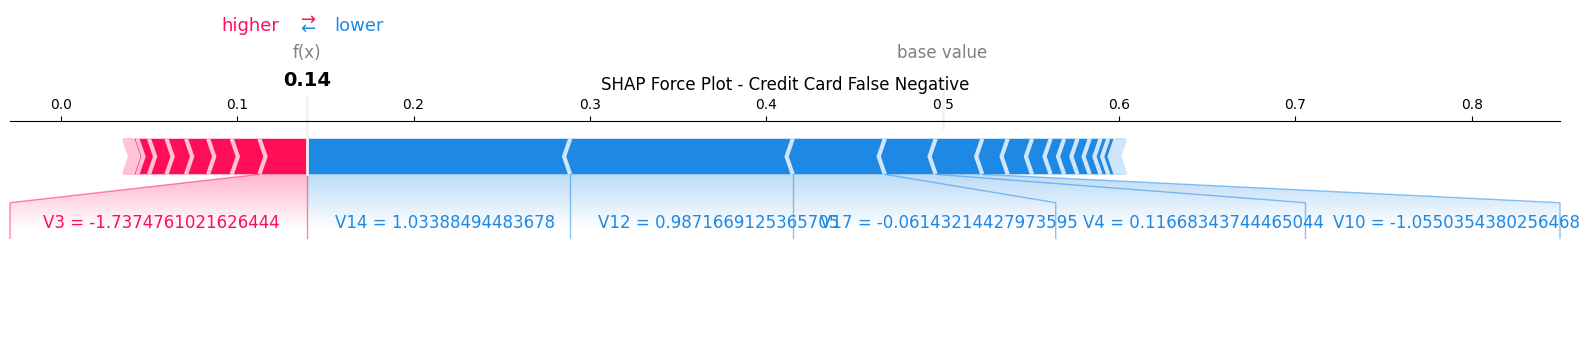

In [13]:
shap.force_plot(
    credit_base_value,
    credit_case_shap_values_class_1[2],
    X_credit_cases_df.iloc[2],
    feature_names=credit_feature_names,
    matplotlib=True,
    show=False
)

plt.title("SHAP Force Plot - Credit Card False Negative")
plt.savefig("../reports/credit_force_plot_false_negative.png", bbox_inches="tight")
plt.show()

In [20]:
import os

files_to_check = [
    "../reports/fraud_top10_feature_importance.png",
    "../reports/fraud_shap_summary.png",
    "../reports/fraud_force_plot_true_positive.png",
    "../reports/fraud_force_plot_false_positive.png",
    "../reports/fraud_force_plot_false_negative.png"
]

for file in files_to_check:
    print(file, "exists:", os.path.exists(file))

../reports/fraud_top10_feature_importance.png exists: True
../reports/fraud_shap_summary.png exists: True
../reports/fraud_force_plot_true_positive.png exists: True
../reports/fraud_force_plot_false_positive.png exists: True
../reports/fraud_force_plot_false_negative.png exists: True
